# Decision Tree using scikit-learn (`criterion='entropy'`)

This notebook shows how to build a decision tree for the **Play Tennis** dataset using **scikit-learn**.

## Important note
- `scikit-learn` with `criterion='entropy'` uses **entropy-based splitting**.
- But it is **not the exact textbook ID3 implementation**.
- `scikit-learn` creates **binary splits** like `Outlook <= 0.5` after encoding categorical values into numbers.

So this notebook is useful for:
- understanding entropy-based decision trees in Python
- comparing library output with the textbook ID3 tree


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder


## 1. Create the Play Tennis dataset

In [2]:
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain',
                'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny',
                'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool',
                    'Cool', 'Mild', 'Cool', 'Mild', 'Mild',
                    'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong',
             'Strong', 'Weak', 'Weak', 'Weak', 'Strong',
             'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No',
                   'Yes', 'No', 'Yes', 'Yes', 'Yes',
                   'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
df

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


## 2. Encode categorical values into numbers

`scikit-learn` requires numeric input for this model, so we encode each categorical column.

In [3]:
df_encoded = df.copy()
encoders = {}

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

df_encoded

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


## 3. Display encoding mappings

This helps us understand what values are used inside the tree.

In [4]:
for col, le in encoders.items():
    print(f"\n{col} mapping:")
    for i, cls in enumerate(le.classes_):
        print(f"  {cls} -> {i}")



Outlook mapping:
  Overcast -> 0
  Rain -> 1
  Sunny -> 2

Temperature mapping:
  Cool -> 0
  Hot -> 1
  Mild -> 2

Humidity mapping:
  High -> 0
  Normal -> 1

Wind mapping:
  Strong -> 0
  Weak -> 1

PlayTennis mapping:
  No -> 0
  Yes -> 1


## 4. Split features and target

In [5]:
X = df_encoded.drop('PlayTennis', axis=1)
y = df_encoded['PlayTennis']

print('Features:')
print(X.head())
print('\nTarget:')
print(y.head())


Features:
   Outlook  Temperature  Humidity  Wind
0        2            1         0     1
1        2            1         0     0
2        0            1         0     1
3        1            2         0     1
4        1            0         1     1

Target:
0    0
1    0
2    1
3    1
4    1
Name: PlayTennis, dtype: int64


## 5. Train the entropy-based decision tree

Here `criterion='entropy'` tells scikit-learn to use entropy for splitting.

In [6]:
model = DecisionTreeClassifier(criterion='entropy', random_state=0)
model.fit(X, y)

print('Model trained successfully.')


Model trained successfully.


## 6. Plot the decision tree

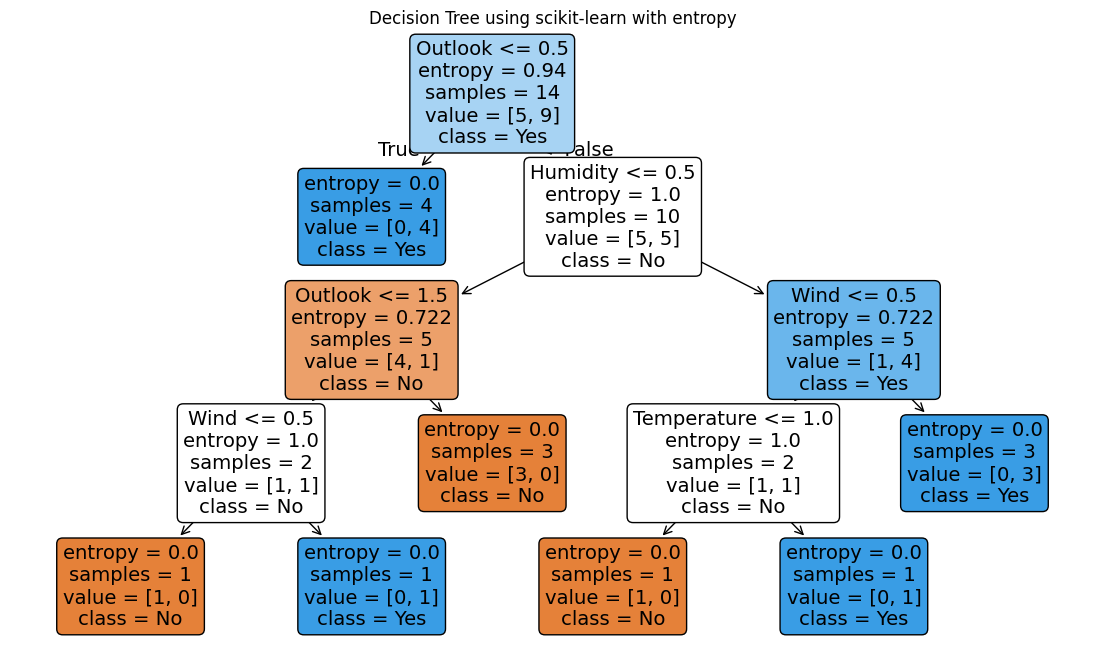

In [7]:
plt.figure(figsize=(14, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=encoders['PlayTennis'].classes_,
    filled=True,
    rounded=True
)
plt.title('Decision Tree using scikit-learn with entropy')
plt.show()


## 7. Print the tree in text form

This is useful when plotting is not enough.

In [8]:
tree_rules = export_text(model, feature_names=list(X.columns))
print(tree_rules)


|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Outlook <= 1.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Wind >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Outlook >  1.50
|   |   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- Temperature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  1.00
|   |   |   |   |--- class: 1
|   |   |--- Wind >  0.50
|   |   |   |--- class: 1



## 8. Predict on training data

In [9]:
predictions = model.predict(X)

result = df.copy()
result['Predicted'] = encoders['PlayTennis'].inverse_transform(predictions)
result['Actual'] = df['PlayTennis']
result['Match'] = result['Predicted'] == result['Actual']
result


,Outlook,Temperature,Humidity,Wind,PlayTennis,Predicted,Actual,Match
0,Sunny,Hot,High,Weak,No,No,No,True
1,Sunny,Hot,High,Strong,No,No,No,True
2,Overcast,Hot,High,Weak,Yes,Yes,Yes,True
3,Rain,Mild,High,Weak,Yes,Yes,Yes,True
4,Rain,Cool,Normal,Weak,Yes,Yes,Yes,True
5,Rain,Cool,Normal,Strong,No,No,No,True
6,Overcast,Cool,Normal,Strong,Yes,Yes,Yes,True
7,Sunny,Mild,High,Weak,No,No,No,True
8,Sunny,Cool,Normal,Weak,Yes,Yes,Yes,True
9,Rain,Mild,Normal,Weak,Yes,Yes,Yes,True


## 9. Accuracy

In [10]:
accuracy = model.score(X, y)
print(f'Accuracy on training data: {accuracy:.2f}')


Accuracy on training data: 1.00


## 10. Predict for a new sample

Example input:
- Outlook = Sunny
- Temperature = Cool
- Humidity = High
- Wind = Strong


In [11]:
new_sample = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
})

new_sample_encoded = new_sample.copy()
for col in new_sample_encoded.columns:
    new_sample_encoded[col] = encoders[col].transform(new_sample_encoded[col])

prediction = model.predict(new_sample_encoded)
predicted_label = encoders['PlayTennis'].inverse_transform(prediction)

print('New sample:')
print(new_sample)
print('\nPredicted class:', predicted_label[0])


New sample:
  Outlook Temperature Humidity    Wind
0   Sunny        Cool     High  Strong

Predicted class: No


## 11. Restrict tree depth (optional)

This creates a smaller tree that may be easier to explain in class.

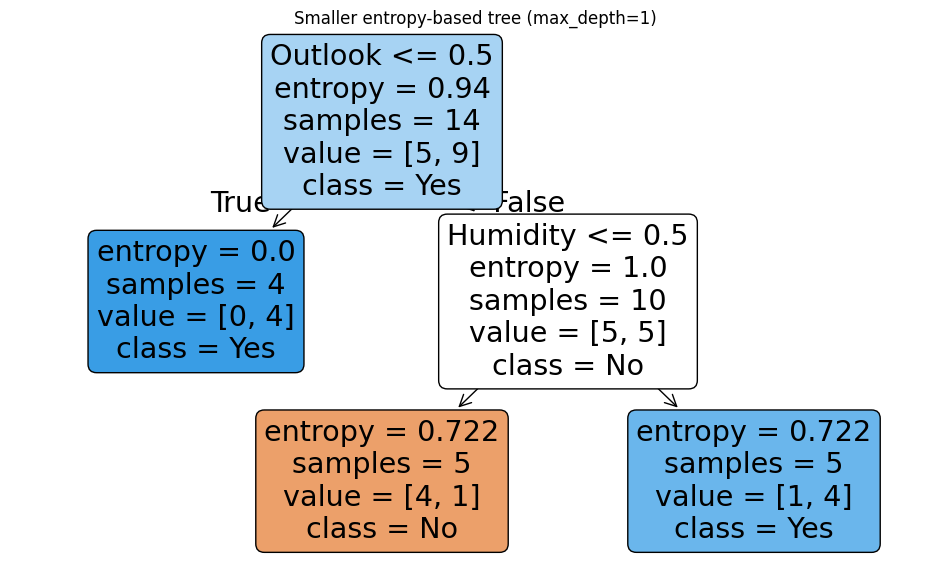

In [12]:
model_small = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=0)
model_small.fit(X, y)

plt.figure(figsize=(12, 7))
plot_tree(
    model_small,
    feature_names=X.columns,
    class_names=encoders['PlayTennis'].classes_,
    filled=True,
    rounded=True
)
plt.title('Smaller entropy-based tree (max_depth=1)')
plt.show()


## Final note

This notebook uses `criterion='entropy'`, so the splitting measure is based on entropy.

However, because scikit-learn uses:
- numeric encoding
- binary splits

the resulting tree may not match the exact **textbook ID3 multi-way tree**.

So for teaching:
- use **manual ID3** for textbook explanation
- use this notebook for **Python implementation with scikit-learn**
